# Importing the libraries

In [3]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Importing dataset 

In [4]:
# Importing the dataset

df = pd.read_csv(r'C:\Users\user\OneDrive\Documents\ML-0027-HumanDevelopmentIndex\ML-0027-HumanDevelopmentIndex\Dataset\HDI.csv')
df
df.head()

,HDI rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank.1
0,1,Switzerland,0.962,84.0,16.5,13.9,"66,933",5,3
1,2,Norway,0.961,83.2,18.2,13.0,"64,660",6,1
2,3,Iceland,0.959,82.7,19.2,13.8,"55,782",11,2
3,4,"Hong Kong, China (SAR)",0.952,85.5,17.3,12.2,"62,607",6,4
4,5,Australia,0.951,84.5,21.1,12.7,"49,238",18,5


In [5]:
# Unique Country Values
df["Country"].unique()

array(['Switzerland', 'Norway', 'Iceland', 'Hong Kong, China (SAR)',
       'Australia', 'Denmark', 'Sweden', 'Ireland', 'Germany',
       'Netherlands', 'Finland', 'Singapore', 'Belgium', 'New Zealand',
       'Canada', 'Liechtenstein', 'Luxembourg', 'United Kingdom', 'Japan',
       'Korea (Republic of)', 'United States', 'Israel', 'Malta',
       'Slovenia', 'Austria', 'United Arab Emirates', 'Spain', 'France',
       'Cyprus', 'Italy', 'Estonia', 'Czechia', 'Greece', 'Poland',
       'Bahrain', 'Lithuania', 'Saudi Arabia', 'Portugal', 'Latvia',
       'Andorra', 'Croatia', 'Chile', 'Qatar', 'San Marino', 'Slovakia',
       'Hungary', 'Argentina', 'Türkiye', 'Montenegro', 'Kuwait',
       'Brunei Darussalam', 'Russian Federation', 'Romania', 'Oman',
       'Bahamas', 'Kazakhstan', 'Trinidad and Tobago', 'Costa Rica',
       'Uruguay', 'Belarus', 'Panama', 'Malaysia', 'Georgia', 'Mauritius',
       'Serbia', 'Thailand', 'Albania', 'Bulgaria', 'Grenada', 'Barbados',
       'Antigua an

# Data Vizualization
We will perform ten visualization tasks to understand the relationships between HDI and key input features. All visualizations use the first 20 rows (data1) to avoid overcrowding in plots.

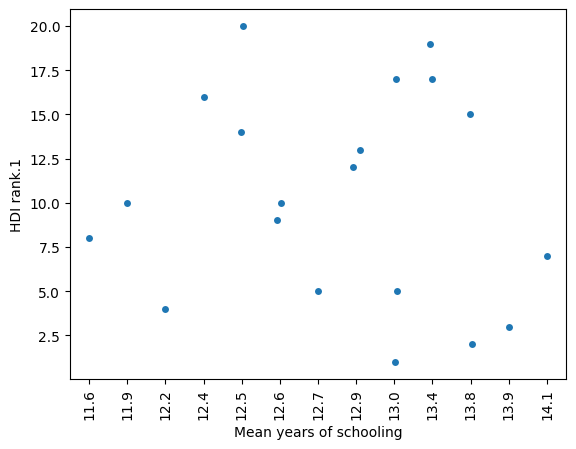

In [6]:
#scatter plot
#Mean year of schooling
g = sns.stripplot(
    x="Mean years of schooling",
    y="HDI rank.1",
    data=df.head(20),
    jitter=True
)

plt.xticks(rotation=90)
plt.show()

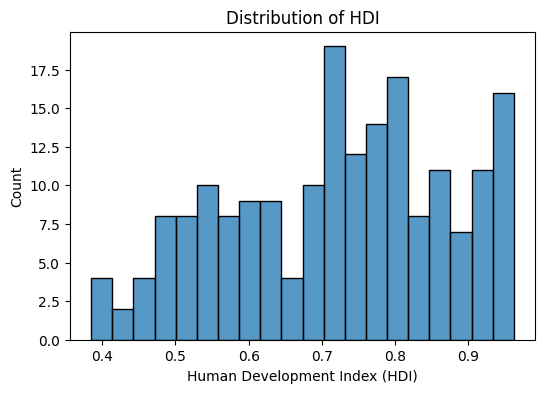

In [7]:
# Histogram Visualization
plt.figure(figsize=(6,4))

sns.histplot(df["Human Development Index (HDI)"], bins=20)

plt.title("Distribution of HDI")
plt.show()

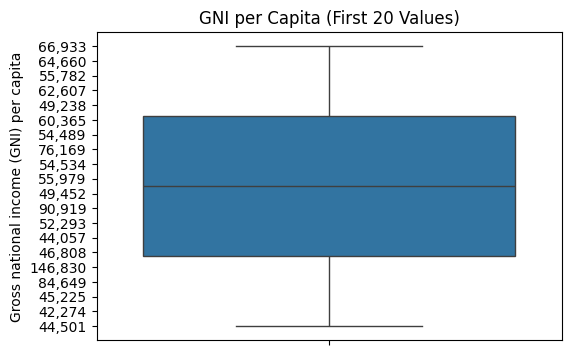

In [8]:
#Box Plot of GNI
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["Gross national income (GNI) per capita"].head(20)
)

plt.title("GNI per Capita (First 20 Values)")
plt.show()

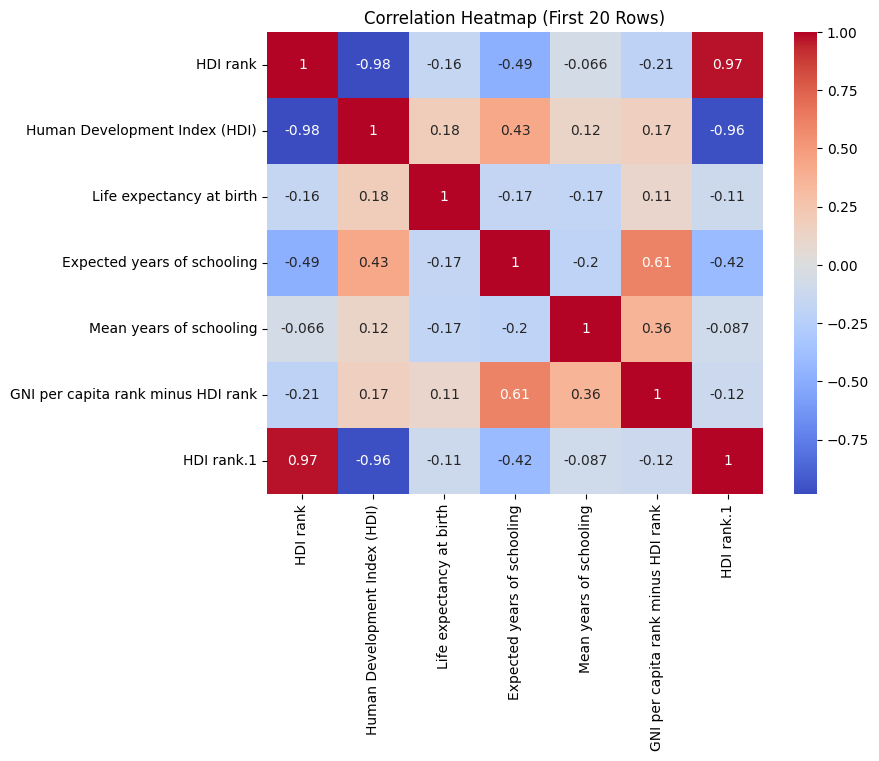

In [9]:
 #Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.head(20).corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (First 20 Rows)")
plt.show()

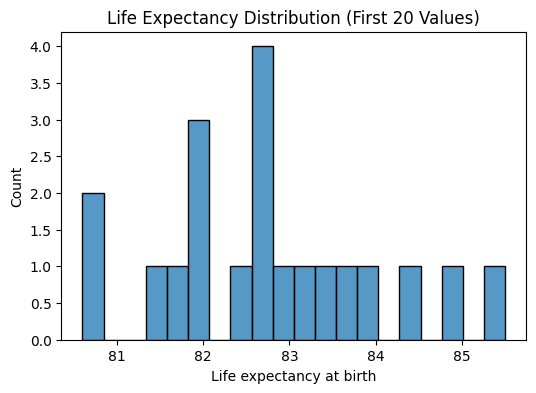

In [10]:
#Histogram of Life Expectancy
plt.figure(figsize=(6,4))

sns.histplot(
    df["Life expectancy at birth"].head(20),
    bins=20
)

plt.title("Life Expectancy Distribution (First 20 Values)")
plt.show()

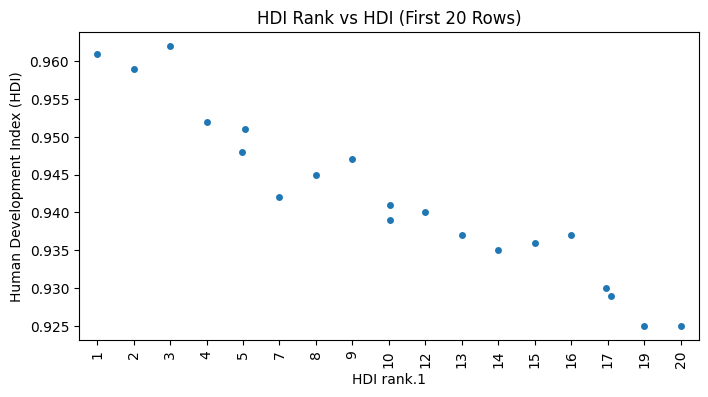

In [11]:
#Strip Plot
plt.figure(figsize=(8,4))

sns.stripplot(
    x="HDI rank.1",
    y="Human Development Index (HDI)",
    data=df.head(20),
    jitter=True
)

plt.xticks(rotation=90)

plt.title("HDI Rank vs HDI (First 20 Rows)")
plt.show()

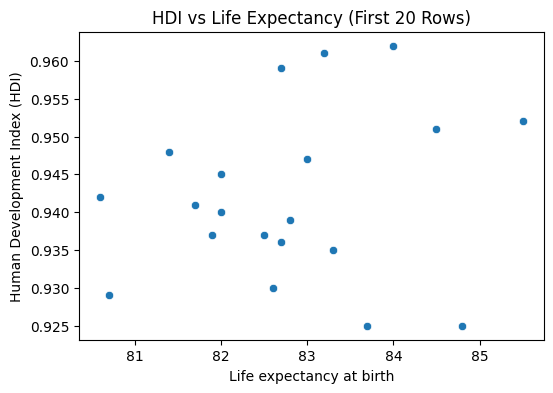

In [12]:
#Scatter Plot (HDI vs Life Expectancy)
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Life expectancy at birth",
    y="Human Development Index (HDI)",
    data=df.head(20)
)

plt.title("HDI vs Life Expectancy (First 20 Rows)")
plt.show()

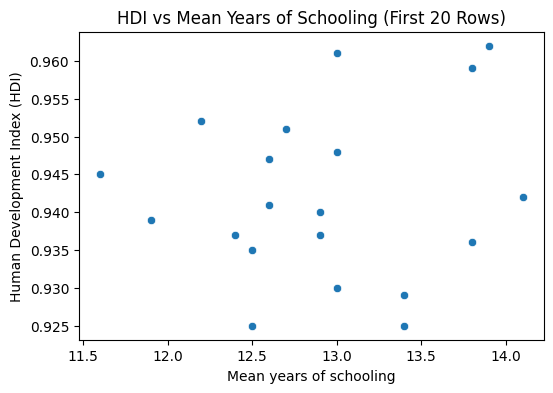

In [13]:
#Scatter Plot (HDI vs Mean Years of Schooling)
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Mean years of schooling",
    y="Human Development Index (HDI)",
    data=df.head(20)
)

plt.title("HDI vs Mean Years of Schooling (First 20 Rows)")
plt.show()

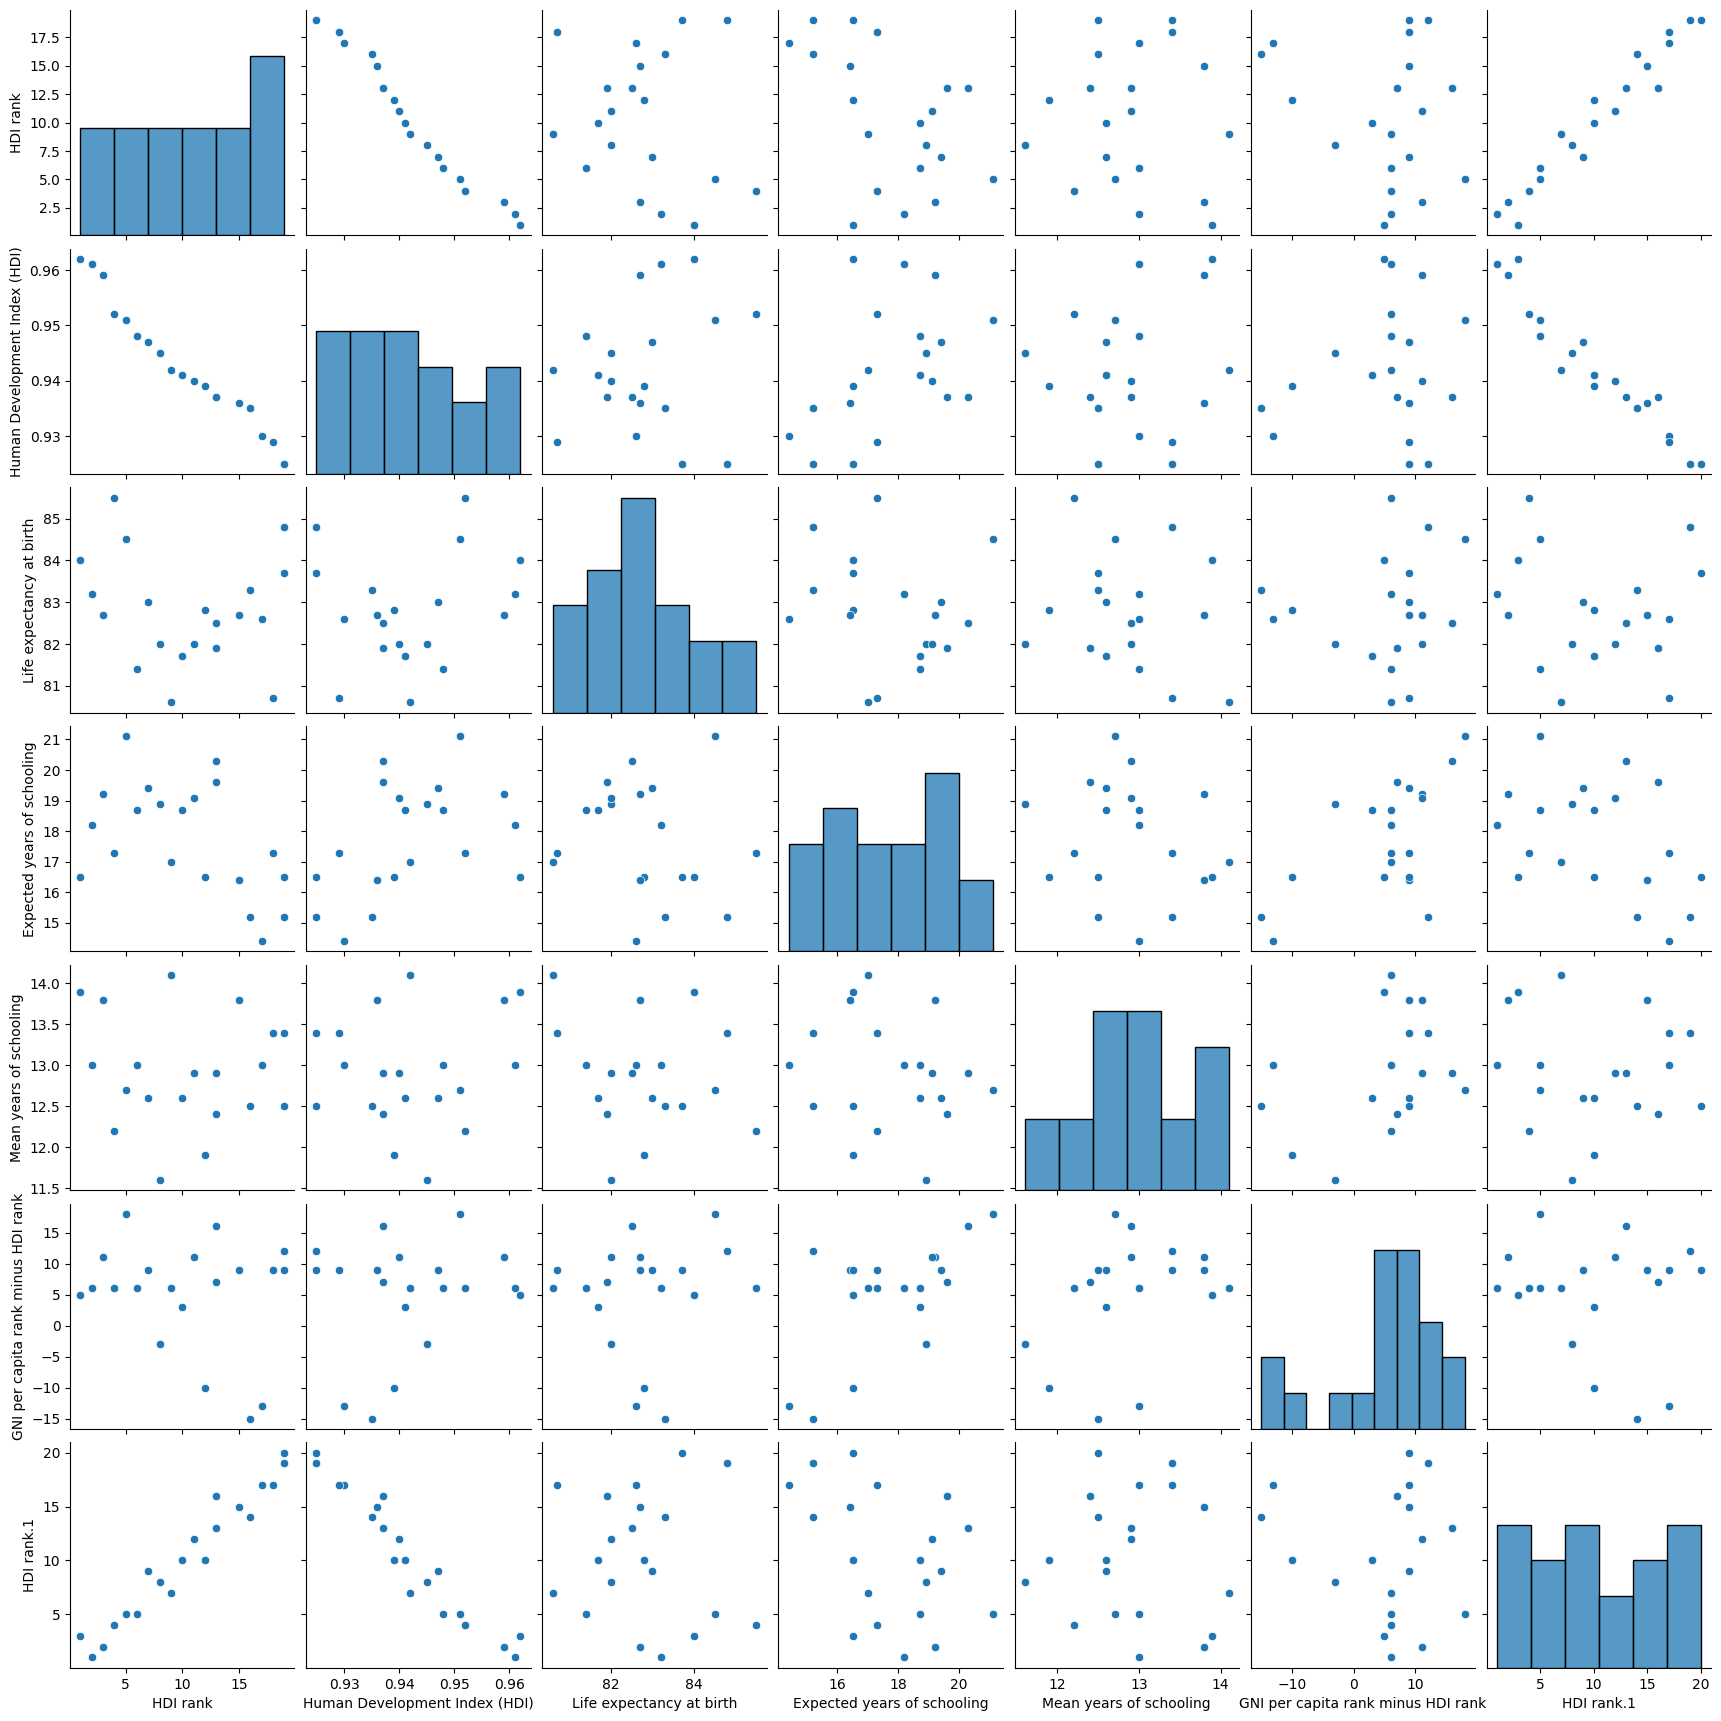

In [14]:
# Pair Plot (First 20 Rows)

sns.pairplot(df.head(20))

plt.show()

In [24]:
print(df.dtypes)

HDI rank                                    int64
Country                                    object
Human Development Index (HDI)             float64
Life expectancy at birth                  float64
Expected years of schooling               float64
Mean years of schooling                   float64
Gross national income (GNI) per capita     object
GNI per capita rank minus HDI rank          int64
HDI rank.1                                  int64
dtype: object


In [26]:
df['Gross national income (GNI) per capita'] = (
    df['Gross national income (GNI) per capita']
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [27]:
print(df.dtypes)

HDI rank                                    int64
Country                                    object
Human Development Index (HDI)             float64
Life expectancy at birth                  float64
Expected years of schooling               float64
Mean years of schooling                   float64
Gross national income (GNI) per capita    float64
GNI per capita rank minus HDI rank          int64
HDI rank.1                                  int64
dtype: object


In [31]:
# Independent variables
X = df.iloc[:, 3:7]

# Dependent variable
Y = df.iloc[:, 2]

In [32]:
# Find Null Values:
X.isnull().sum()

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64

In [33]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [34]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", Y_train.shape)
print("Testing Target:", Y_test.shape)

Training Features: (152, 4)
Testing Features: (39, 4)
Training Target: (152,)
Testing Target: (39,)


In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [35]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.01,0.01,0.02,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Life expectancy at birth','Expected years of schooling', 'Mean years of schooling','Gross national income (GNI) per capita']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.07651
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [36]:
Y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [38]:
print("R² Score:", r2_score(Y_test, Y_pred))
print("Mean Absolute Error:", mean_absolute_error(Y_test, Y_pred))
print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(Y_test, Y_pred)))

R² Score: 0.9732135879688296
Mean Absolute Error: 0.016039716500521644
Mean Squared Error: 0.0006320773620936789
Root Mean Squared Error: 0.02514114878229869


In [39]:
sample = [[72.5, 15.5, 10.2, 25000]]

prediction = model.predict(sample)

print("Predicted HDI:", prediction[0])

Predicted HDI: 0.7816536244182914


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [40]:
import pickle

with open("HDI.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
